# AG_PRAXIS NB02 — Class and Capture Distribution

This notebook works out how the dataset is organised: which classes exist, how many
separate recordings each one came from, and how far apart the class sizes are.

The reason this comes before any model is that the splitting protocol depends on it. If
a class was recorded once, there is no way to hold out a whole recording of it without
losing the class entirely, and every claim about capture-disjoint evaluation has to be
qualified for exactly those classes. I would rather know which ones they are now than
discover it while writing up a result.

The columns themselves were established already and are read from
`data/processed/schema.json` rather than worked out again here. What this notebook adds
is one check on them that is cheap to run and expensive to skip: whether any column
holds a single value inside a capture file while differing between capture files. A
column like that is a label for the recording session, and a model reading it is not
doing what I think it is doing.

A notebook running in Colab cannot commit, so anything written into the cloned
repository disappears when the session ends. Every file produced here is written to the
artefacts folder on Drive, and the contents of each one are printed near the end so
they survive inside this notebook as well. No model is trained.

Mount Drive, clone the repository so that `src/` can be imported, and record the commit
the results belong to. The repository is read from and never written to.

In [1]:
import os
import subprocess
import sys
from datetime import date
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AGREWAL14/AG_PRAXIS.git"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    REPO_ROOT = Path("/content/repo")
    if REPO_ROOT.exists():
        subprocess.run(["git", "-C", str(REPO_ROOT), "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
else:
    REPO_ROOT = Path.cwd()
    while not (REPO_ROOT / "config" / "base.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
        REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def git(*args):
    return subprocess.run(
        ["git", "-C", str(REPO_ROOT), *args], capture_output=True, text=True
    ).stdout.strip()


GIT_SHA = git("rev-parse", "--short", "HEAD")
GIT_BRANCH = git("rev-parse", "--abbrev-ref", "HEAD")
GIT_DIRTY = bool(git("status", "--porcelain"))
RUN_DATE = date.today().isoformat()

print(f"colab     : {IN_COLAB}")
print(f"repo root : {REPO_ROOT}")
print(f"git sha   : {GIT_SHA} on {GIT_BRANCH}" + ("   WORKING TREE DIRTY" if GIT_DIRTY else ""))
print(f"run date  : {RUN_DATE}")

Mounted at /content/drive
colab     : True
repo root : /content/repo
git sha   : ba7bd64 on main
run date  : 2026-08-02


Paths and the seed come from `config/base.yaml`, and the column list comes from
`data/processed/schema.json`, so this notebook works from the schema that was checked
when it was written rather than from whatever the first file happens to contain today.
If that file is missing there is no point continuing, so it stops.

Everything this notebook writes goes to one folder on Drive, which is created here, and
it stops just as fast if Drive is not where it is supposed to be. Failing at the start
costs a minute. Failing after the scan costs the scan.

`FAST` shortens the column scan and nothing else. Row counts are exact in either case,
for the reason given further down.

In [2]:
import json
import random

import numpy as np
import pandas as pd

from src import captures as cap
from src import inventory as inv

CFG = inv.load_config(REPO_ROOT)

SEED = CFG["seed"]
TRAIN_DIR = Path(CFG["paths"]["train_dir"])
TEST_DIR = Path(CFG["paths"]["test_dir"])
ARTIFACTS = Path(CFG["paths"]["artifacts"])
OUT_DIR = ARTIFACTS / "NB02"

SCHEMA_PATH = REPO_ROOT / "data" / "processed" / "schema.json"
if not SCHEMA_PATH.exists():
    raise FileNotFoundError(f"{SCHEMA_PATH} not found in the repository.")
SCHEMA = json.loads(SCHEMA_PATH.read_text())
SCHEMA_COLUMNS = SCHEMA["columns"]

if IN_COLAB and not ARTIFACTS.exists():
    raise FileNotFoundError(
        f"{ARTIFACTS} does not exist. Drive is not mounted, or the artefacts path in "
        "config/base.yaml is wrong. Nothing this notebook writes would survive."
    )
OUT_DIR.mkdir(parents=True, exist_ok=True)

FAST = os.environ.get("FAST", "1") == "1"
SUBSAMPLE_FRAC = CFG["fast_mode"]["subsample_frac"]
SCAN_FRAC = SUBSAMPLE_FRAC if FAST else 1.0
SCAN_FULL = not FAST

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

print(f"seed       : {SEED}")
print(f"train dir  : {TRAIN_DIR}   exists={TRAIN_DIR.exists()}")
print(f"test dir   : {TEST_DIR}   exists={TEST_DIR.exists()}")
print(f"output dir : {OUT_DIR}")
print()
print(f"schema.json written on {SCHEMA['generated_on']} at sha {SCHEMA['git_sha']}")
print(f"  reference file  : {SCHEMA['reference_file']}")
print(f"  columns         : {SCHEMA['n_columns']}")
print(f"  files covered   : {SCHEMA['n_files']}")
print(f"  timestamp       : {SCHEMA['has_timestamp']}")
print(f"  endpoint ids    : {SCHEMA['has_endpoint_identifiers']}")
print(f"  schema uniform  : {SCHEMA['schema_identical_across_files']}")
if SCHEMA.get("fast_mode"):
    print("  That run had FAST=1, so its dtype pass covered part of the corpus only.")
    print("  The column list and the two verdicts came from a pass over every file.")
print()
print(f"FAST       : {int(FAST)}")
print(f"column scan reads : {'every row of every file' if SCAN_FULL else f'the first {SCAN_FRAC:.0%} of each file'}")
if FAST:
    print("             Row counts stay exact. The column checks are a screen only.")
    print("             A run entered in the ledger requires FAST=0.")

seed       : 42
train dir  : /content/drive/MyDrive/AG_PRAXIS_data/csv/train   exists=True
test dir   : /content/drive/MyDrive/AG_PRAXIS_data/csv/test   exists=True
output dir : /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02

schema.json written on 2026-08-02 at sha d3f634b
  reference file  : ARP_Spoofing_train.pcap.csv
  columns         : 45
  files covered   : 72
  timestamp       : False
  endpoint ids    : False
  schema uniform  : True
  That run had FAST=1, so its dtype pass covered part of the corpus only.
  The column list and the two verdicts came from a pass over every file.

FAST       : 1
column scan reads : the first 1% of each file
             Row counts stay exact. The column checks are a screen only.
             A run entered in the ledger requires FAST=0.


No model is built here, but the seed is set before anything else runs so that whatever
sampling happens gives the same rows the next time.

In [3]:
random.seed(SEED)
np.random.seed(SEED)
print(f"seeded with {SEED}")

seeded with 42


Every file name encodes three things: which recording session it came from, which class
that session was recording, and which side of the distributed split it belongs to.
`parse_capture` in `src/captures.py` is the one place that rule is written down. Putting
it in the repository rather than in a cell means the notebooks after this one cannot
quietly disagree with it about what a class is.

The rule reads the trailing digits of a name as the capture number within a class, so
stripping them gives the class. `TCP_IP-` is a grouping used in the filenames rather
than part of a class name, and `ARP_Spoofing` is the filename spelling of the class
called Spoofing.

In [4]:
train_files = sorted(TRAIN_DIR.glob("*.csv"))
test_files = sorted(TEST_DIR.glob("*.csv"))
ALL_FILES = train_files + test_files
EXPECTED_FILES = 72

parsed = pd.DataFrame([{"file": p.name, **cap.parse_capture(p.name)} for p in ALL_FILES])
parsed["path"] = [str(p) for p in ALL_FILES]

print(f"files parsed : {len(parsed)}   (expected {EXPECTED_FILES})")
if len(parsed) != EXPECTED_FILES:
    print(f"MISMATCH: found {len(parsed)} files, not {EXPECTED_FILES}. Check the paths above.")
print()
print("how the rule reads the first few names:")
print(parsed[["file", "capture_id", "label", "partition"]].head(6).to_string(index=False))

files parsed : 72   (expected 72)

how the rule reads the first few names:
                                  file              capture_id                   label partition
           ARP_Spoofing_train.pcap.csv            ARP_Spoofing                Spoofing     train
                 Benign_train.pcap.csv                  Benign                  Benign     train
MQTT-DDoS-Connect_Flood_train.pcap.csv MQTT-DDoS-Connect_Flood MQTT-DDoS-Connect_Flood     train
MQTT-DDoS-Publish_Flood_train.pcap.csv MQTT-DDoS-Publish_Flood MQTT-DDoS-Publish_Flood     train
 MQTT-DoS-Connect_Flood_train.pcap.csv  MQTT-DoS-Connect_Flood  MQTT-DoS-Connect_Flood     train
 MQTT-DoS-Publish_Flood_train.pcap.csv  MQTT-DoS-Publish_Flood  MQTT-DoS-Publish_Flood     train


Now the table the rest of the notebook rests on. One row per class, listing the captures
it was recorded in on each side of the distributed split, and how many of each. Nineteen
classes is the number the project is built around, so it is asserted rather than
assumed.

In [5]:
def capture_list(group, partition):
    return sorted(group.loc[group["partition"] == partition, "capture_id"].unique())


rows = []
for label, group in parsed.groupby("label"):
    train_caps = capture_list(group, "train")
    test_caps = capture_list(group, "test")
    rows.append(
        {
            "label": label,
            "n_train_captures": len(train_caps),
            "n_test_captures": len(test_caps),
            "captures_train": train_caps,
            "captures_test": test_caps,
        }
    )

classes = pd.DataFrame(rows).sort_values("label").reset_index(drop=True)

printable = classes.assign(
    captures_train=classes["captures_train"].map(", ".join),
    captures_test=classes["captures_test"].map(", ".join),
)
print(printable.to_string(index=False))
print()

N_CLASSES = len(classes)
print(f"distinct classes : {N_CLASSES}")
print(f"train files      : {(parsed['partition'] == 'train').sum()}")
print(f"test files       : {(parsed['partition'] == 'test').sum()}")
print(f"distinct captures: {parsed['capture_id'].nunique()}")

assert N_CLASSES == 19, f"expected 19 classes, found {N_CLASSES}: {sorted(classes['label'])}"
print()
print("19 classes confirmed.")

                  label  n_train_captures  n_test_captures                                                                                                                                         captures_train                        captures_test
                 Benign                 1                1                                                                                                                                                 Benign                               Benign
              DDoS-ICMP                 8                2 TCP_IP-DDoS-ICMP1, TCP_IP-DDoS-ICMP2, TCP_IP-DDoS-ICMP3, TCP_IP-DDoS-ICMP4, TCP_IP-DDoS-ICMP5, TCP_IP-DDoS-ICMP6, TCP_IP-DDoS-ICMP7, TCP_IP-DDoS-ICMP8 TCP_IP-DDoS-ICMP1, TCP_IP-DDoS-ICMP2
               DDoS-SYN                 4                1                                                                                 TCP_IP-DDoS-SYN1, TCP_IP-DDoS-SYN2, TCP_IP-DDoS-SYN3, TCP_IP-DDoS-SYN4                      TCP_IP-DDoS-SYN
            

One thing in that table needs saying out loud before the tiers make sense. A capture id
appearing on both sides means the same recording session was cut in half and put into
both partitions of the distributed split. The next block counts how many do that.

Where it happens, the shipped split is a cut inside a recording rather than a separation
of recordings, and a model evaluated on it is being tested on the remainder of a session
it was trained on. That is the thing this project sets out to measure, so it is worth
confirming rather than asserting.

In [6]:
by_capture = parsed.groupby("capture_id")["partition"].agg(set)
in_both = sorted(c for c, parts in by_capture.items() if parts == {"train", "test"})
train_only = sorted(c for c, parts in by_capture.items() if parts == {"train"})
test_only = sorted(c for c, parts in by_capture.items() if parts == {"test"})

print(f"captures in both partitions : {len(in_both)} of {len(by_capture)}")
print(f"captures in train only      : {len(train_only)}")
print(f"captures in test only       : {len(test_only)}")
print()
if in_both:
    print("split across both partitions:")
    for c in in_both:
        print(f"  {c}")
    print()

shared_classes = sorted(parsed.loc[parsed["capture_id"].isin(in_both), "label"].unique())

if len(in_both) == len(by_capture):
    print("Every recording session contributes to both sides of the distributed split.")
    print("No capture is held out by it, so that split cannot answer a question about")
    print("generalising to an unseen recording.")
elif in_both:
    print(f"{len(in_both)} of {len(by_capture)} sessions appear on both sides, covering these")
    print(f"classes: {', '.join(shared_classes)}.")
    print("For those classes the distributed split is a cut inside a recording rather")
    print("than a separation of recordings, so a model is tested on the remainder of a")
    print("session it was trained on.")
else:
    print("No session appears on both sides. The distributed split already separates")
    print("recordings, and the capture-disjoint protocol changes which recordings go")
    print("where rather than whether they are separated at all.")
print()
print("Either way the split used for every result in this project is the")
print(f"capture-disjoint one named in config/base.yaml: {CFG['split']['protocol']}.")

captures in both partitions : 15 of 57
captures in train only      : 36
captures in test only       : 6

split across both partitions:
  ARP_Spoofing
  Benign
  MQTT-DDoS-Connect_Flood
  MQTT-DDoS-Publish_Flood
  MQTT-DoS-Connect_Flood
  MQTT-DoS-Publish_Flood
  MQTT-Malformed_Data
  Recon-OS_Scan
  Recon-Ping_Sweep
  Recon-Port_Scan
  Recon-VulScan
  TCP_IP-DDoS-ICMP1
  TCP_IP-DDoS-ICMP2
  TCP_IP-DDoS-UDP1
  TCP_IP-DDoS-UDP2

15 of 57 sessions appear on both sides, covering these
classes: Benign, DDoS-ICMP, DDoS-UDP, MQTT-DDoS-Connect_Flood, MQTT-DDoS-Publish_Flood, MQTT-DoS-Connect_Flood, MQTT-DoS-Publish_Flood, MQTT-Malformed_Data, Recon-OS_Scan, Recon-Ping_Sweep, Recon-Port_Scan, Recon-VulScan, Spoofing.
For those classes the distributed split is a cut inside a recording rather
than a separation of recordings, so a model is tested on the remainder of a
session it was trained on.

Either way the split used for every result in this project is the
capture-disjoint one named in config/

The tier follows directly. A class recorded in more than one training capture can have a
whole capture held out and still be represented in what remains. A class recorded once
cannot, so for those the only split available is a cut inside a single recording, which
is the very thing the protocol is meant to avoid.

Tier B is not a failure of the split, it is a limit of the dataset, and any result
covering those classes has to carry that qualification. Eight in tier A and eleven in
tier B is what I expect from the file names, so the notebook checks it.

In [7]:
classes["tier"] = np.where(classes["n_train_captures"] > 1, "A", "B")

tier_a = classes.loc[classes["tier"] == "A", "label"].tolist()
tier_b = classes.loc[classes["tier"] == "B", "label"].tolist()

print("Tier A, more than one training capture, whole captures can be held out")
for label in tier_a:
    n = int(classes.loc[classes["label"] == label, "n_train_captures"].iloc[0])
    print(f"  {label:<28} {n} training captures")
print()
print("Tier B, one training capture, only a within-capture split is possible")
for label in tier_b:
    print(f"  {label}")
print()
print(f"tier A : {len(tier_a)}   expected 8")
print(f"tier B : {len(tier_b)}   expected 11")

if (len(tier_a), len(tier_b)) != (8, 11):
    print()
    print(f"DIFFERS FROM EXPECTATION: got {len(tier_a)} in A and {len(tier_b)} in B.")
    print("Tier A:", tier_a)
    print("Tier B:", tier_b)

assert (len(tier_a), len(tier_b)) == (8, 11), (
    f"expected 8 in tier A and 11 in tier B, got {len(tier_a)} and {len(tier_b)}"
)
print()
print("Tier split confirmed at 8 and 11.")

Tier A, more than one training capture, whole captures can be held out
  DDoS-ICMP                    8 training captures
  DDoS-SYN                     4 training captures
  DDoS-TCP                     4 training captures
  DDoS-UDP                     8 training captures
  DoS-ICMP                     4 training captures
  DoS-SYN                      4 training captures
  DoS-TCP                      4 training captures
  DoS-UDP                      4 training captures

Tier B, one training capture, only a within-capture split is possible
  Benign
  MQTT-DDoS-Connect_Flood
  MQTT-DDoS-Publish_Flood
  MQTT-DoS-Connect_Flood
  MQTT-DoS-Publish_Flood
  MQTT-Malformed_Data
  Recon-OS_Scan
  Recon-Ping_Sweep
  Recon-Port_Scan
  Recon-VulScan
  Spoofing

tier A : 8   expected 8
tier B : 11   expected 11

Tier split confirmed at 8 and 11.


This cell does two different passes over the files and it is worth being clear about
which number comes from which.

Row counts come from counting newlines across every byte of every file. That is a full
pass over the whole corpus, it does not depend on `FAST`, and the count is checked
against the parser so the shortcut is not taken on trust.

The second pass parses the rows to see what each column looks like inside each file, and
that is the expensive one. `FAST` shortens it to the opening rows of each file, which is
enough to check that the code runs and not enough to conclude anything about a column,
because a slice of a session can look constant when the session is not. When `FAST=0`
the two passes are compared file by file, which is also the check on the newline
counting.

In [8]:
print(f"counting rows in {len(ALL_FILES)} files")
row_counts = {p.name: cap.count_data_rows(p) for p in ALL_FILES}
parsed["rows"] = [row_counts[p.name] for p in ALL_FILES]
print(f"total rows : {int(parsed['rows'].sum()):,}")
print()

print(f"scanning columns at fraction {SCAN_FRAC}")
scans = cap.scan_captures(ALL_FILES, frac=SCAN_FRAC, known_rows=row_counts)
parsed["rows_parsed"] = [scans[p.name]["n_rows_read"] for p in ALL_FILES]
print("done")
print()

if SCAN_FULL:
    disagree = parsed.loc[parsed["rows"] != parsed["rows_parsed"], ["file", "rows", "rows_parsed"]]
    if len(disagree):
        print("The newline count and the parser disagree on these files:")
        print(disagree.to_string(index=False))
        print("Something in the data contains a newline. The counts are not trustworthy.")
    else:
        print(f"Newline count and parser agree on all {len(ALL_FILES)} files.")
else:
    probe = ALL_FILES[0]
    probe_parsed = len(pd.read_csv(probe))
    probe_counted = row_counts[probe.name]
    print(f"newline count vs parser on {probe.name} : {probe_counted:,} vs {probe_parsed:,}")
    print("They agree." if probe_counted == probe_parsed else "They disagree. Counts are wrong.")
    print(f"FAST=1, parsed {int(parsed['rows_parsed'].sum()):,} of {int(parsed['rows'].sum()):,} rows.")
    print("Row counts above are still exact. The column checks below are a screen.")

scanned_columns = sorted({c for s in scans.values() for c in s["columns"]})
missing = [c for c in SCHEMA_COLUMNS if c not in scanned_columns]
unexpected = [c for c in scanned_columns if c not in SCHEMA_COLUMNS]
print()
print(f"columns seen in the scan : {len(scanned_columns)}")
print(f"not in schema.json       : {unexpected or 'none'}")
print(f"in schema.json, not seen : {missing or 'none'}")
if unexpected or missing:
    print("The files no longer match the recorded schema. Regenerate schema.json before")
    print("anything below is taken seriously.")

counting rows in 72 files
total rows : 8,775,013

scanning columns at fraction 0.01
  scanned 10/72 files
  scanned 20/72 files
  scanned 30/72 files
  scanned 40/72 files
  scanned 50/72 files
  scanned 60/72 files
  scanned 70/72 files
done

newline count vs parser on ARP_Spoofing_train.pcap.csv : 16,047 vs 16,047
They agree.
FAST=1, parsed 103,704 of 8,775,013 rows.
Row counts above are still exact. The column checks below are a screen.

columns seen in the scan : 45
not in schema.json       : none
in schema.json, not seen : none


Rows per capture first, then rows per class. Sorting by class size rather than by name is
the point of the table, because the shape of the tail is what decides whether
macro-averaging and weighted averaging will disagree.

In [9]:
per_capture = parsed[["file", "capture_id", "label", "partition", "rows"]].sort_values(
    ["label", "partition", "capture_id"]
)

class_sizes = (
    parsed.groupby("label")["rows"].sum().rename("rows").reset_index().merge(classes, on="label")
)
TOTAL_ROWS = int(class_sizes["rows"].sum())
class_sizes["pct_of_total"] = (100 * class_sizes["rows"] / TOTAL_ROWS).round(3)
class_sizes = class_sizes.sort_values("rows", ascending=False).reset_index(drop=True)

print("rows per capture file")
print(per_capture.to_string(index=False))
print()
print("rows per class, largest first")
print(
    class_sizes[["label", "tier", "n_train_captures", "rows", "pct_of_total"]].to_string(index=False)
)
print()
print(f"total rows : {TOTAL_ROWS:,}")

rows per capture file
                                  file              capture_id                   label partition   rows
                  Benign_test.pcap.csv                  Benign                  Benign      test  37607
                 Benign_train.pcap.csv                  Benign                  Benign     train 192732
       TCP_IP-DDoS-ICMP1_test.pcap.csv       TCP_IP-DDoS-ICMP1               DDoS-ICMP      test 154007
       TCP_IP-DDoS-ICMP2_test.pcap.csv       TCP_IP-DDoS-ICMP2               DDoS-ICMP      test 195692
      TCP_IP-DDoS-ICMP1_train.pcap.csv       TCP_IP-DDoS-ICMP1               DDoS-ICMP     train 194938
      TCP_IP-DDoS-ICMP2_train.pcap.csv       TCP_IP-DDoS-ICMP2               DDoS-ICMP     train 194818
      TCP_IP-DDoS-ICMP3_train.pcap.csv       TCP_IP-DDoS-ICMP3               DDoS-ICMP     train 189710
      TCP_IP-DDoS-ICMP4_train.pcap.csv       TCP_IP-DDoS-ICMP4               DDoS-ICMP     train 192741
      TCP_IP-DDoS-ICMP5_train.pcap.csv    

The ratio between the largest and smallest class is the single number that justifies
macro-F1 as the primary metric. If it is large, a model can ignore the bottom of that
table completely and still score well on anything weighted by class size.

In [10]:
largest = class_sizes.iloc[0]
smallest = class_sizes.iloc[-1]
IMBALANCE_RATIO = float(largest["rows"]) / max(float(smallest["rows"]), 1.0)

print("imbalance across the 19 classes")
print()
print(f"largest  : {largest['label']}   {int(largest['rows']):,} rows   {largest['pct_of_total']}%")
print(f"smallest : {smallest['label']}   {int(smallest['rows']):,} rows   {smallest['pct_of_total']}%")
print(f"ratio    : {IMBALANCE_RATIO:,.1f} to 1")
print()
print(f"median class size : {class_sizes['rows'].median():,.0f} rows")
print(f"classes below 1 percent of the total : {(class_sizes['pct_of_total'] < 1).sum()} of 19")
print(f"share held by the largest three : {class_sizes['pct_of_total'].head(3).sum():.1f}%")
print()

share = float(largest["pct_of_total"]) / 100
majority_only_f1 = 2 * share / (1 + share)
majority_only_macro = majority_only_f1 / 19

print("A model that always predicts the largest class and nothing else would score")
print(f"{100 * share:.1f}% accuracy, and a macro-F1 of {majority_only_macro:.3f}.")
print("The distance between those two numbers is why macro-F1 is the primary metric")
print("and why accuracy is never reported on its own.")

imbalance across the 19 classes

largest  : DDoS-UDP   1,998,026 rows   22.769%
smallest : Recon-Ping_Sweep   926 rows   0.011%
ratio    : 2,157.7 to 1

median class size : 214,952 rows
classes below 1 percent of the total : 8 of 19
share held by the largest three : 55.5%

A model that always predicts the largest class and nothing else would score
22.8% accuracy, and a macro-F1 of 0.020.
The distance between those two numbers is why macro-F1 is the primary metric
and why accuracy is never reported on its own.


The 19-class task is the primary one, but the same rows regroup into the coarser tasks
the dataset is usually reported on, so the counts for those come from the same numbers
rather than from a second pass. The grouping is by name: Benign stays as it is, anything
beginning DDoS or DoS becomes that, the MQTT and Recon prefixes become their own groups,
and Spoofing stays. Order matters in exactly one place, because MQTT-DDoS-Connect_Flood
begins with MQTT and not with DDoS, and it belongs to MQTT.

In [11]:
class_sizes["group6"] = class_sizes["label"].map(cap.group_six)
class_sizes["group2"] = class_sizes["label"].map(cap.group_two)

unmapped = class_sizes.loc[class_sizes["group6"] == "UNMAPPED", "label"].tolist()
assert not unmapped, f"labels the 6-class map does not cover: {unmapped}"

six = (
    class_sizes.groupby("group6")
    .agg(classes=("label", "count"), rows=("rows", "sum"))
    .sort_values("rows", ascending=False)
)
six["pct_of_total"] = (100 * six["rows"] / TOTAL_ROWS).round(3)

two = (
    class_sizes.groupby("group2")
    .agg(classes=("label", "count"), rows=("rows", "sum"))
    .sort_values("rows", ascending=False)
)
two["pct_of_total"] = (100 * two["rows"] / TOTAL_ROWS).round(3)

print("6-class grouping")
print(six.to_string())
print(f"ratio largest to smallest : {six['rows'].max() / max(six['rows'].min(), 1):,.1f} to 1")
print()
print("2-class grouping")
print(two.to_string())
print(f"ratio largest to smallest : {two['rows'].max() / max(two['rows'].min(), 1):,.1f} to 1")
print()
print("which 19-class labels fall into each of the six:")
for group, members in class_sizes.groupby("group6")["label"]:
    print(f"  {group:<10} {', '.join(sorted(members))}")

6-class grouping
          classes     rows  pct_of_total
group6                                  
DDoS            4  5846623        66.628
DoS             4  2222205        25.324
MQTT            5   326653         3.723
Benign          1   230339         2.625
Recon           4   131402         1.497
Spoofing        1    17791         0.203
ratio largest to smallest : 328.6 to 1

2-class grouping
        classes     rows  pct_of_total
group2                                
Attack       18  8544674        97.375
Benign        1   230339         2.625
ratio largest to smallest : 37.1 to 1

which 19-class labels fall into each of the six:
  Benign     Benign
  DDoS       DDoS-ICMP, DDoS-SYN, DDoS-TCP, DDoS-UDP
  DoS        DoS-ICMP, DoS-SYN, DoS-TCP, DoS-UDP
  MQTT       MQTT-DDoS-Connect_Flood, MQTT-DDoS-Publish_Flood, MQTT-DoS-Connect_Flood, MQTT-DoS-Publish_Flood, MQTT-Malformed_Data
  Recon      Recon-OS_Scan, Recon-Ping_Sweep, Recon-Port_Scan, Recon-VulScan
  Spoofing   Spoofing


The last check is the one that matters most for whether any later result can be trusted.
For every column, I ask whether it holds a single value throughout a capture file while
taking different values in other capture files.

A column like that is not measuring the traffic, it is naming the recording. Each class
was captured in its own session, so anything that stays fixed for the length of a session
and changes between sessions carries the identity of the session, and the identity of the
session is very nearly the label. A model given such a column can score well by reading
it and never learn anything about the attack.

The schema records no timestamp and no addresses, which rules out the obvious carriers of
capture identity. That makes this worth doing rather than not worth doing: if something
is still naming the recording, it is doing so through a column that does not announce
itself.

The counts below are per file rather than per session, because a session may be stored as
more than one file. A value fixed for a session therefore shows up as constant in each of
its files.

A check that reports nothing is indistinguishable from a check that is not running, so
this one is given something to find. A column is added to the scan holding one value per
file, which is precisely the pattern being looked for. If the check does not flag it,
nothing else it says is worth reading, and the notebook stops.

In [12]:
SHOW = ["column", "constant_in_files", "of_files", "distinct_values_across_files"]
CONTROL = "__planted_capture_marker__"

planted = {
    name: {**scan, "columns": {**scan["columns"], CONTROL: {"n_unique": 1, "value": i}}}
    for i, (name, scan) in enumerate(scans.items())
}
planted_scan = cap.capture_constant_columns(planted)
control_row = planted_scan[planted_scan["column"] == CONTROL].iloc[0]

print("control: a column planted with one value per file")
print(pd.DataFrame([control_row])[SHOW].to_string(index=False))
control_found = bool(control_row["constant_in_every_file"]) and (
    control_row["distinct_values_across_files"] == len(scans)
)
print("Flagged as expected, so the check is working." if control_found else "NOT FLAGGED.")
assert control_found, "the capture-constant check failed to find a planted marker column"
print()

candidates = cap.capture_constant_columns(scans)
label_like = candidates[
    candidates["column"].map(lambda c: any(k in inv.tokenise(c) for k in inv.LABEL_KEYWORDS))
]
features = candidates[~candidates.index.isin(label_like.index)]

if len(label_like):
    print("columns that look like a target by name, excluded from the counts below:")
    print(label_like[SHOW].to_string(index=False))
else:
    print("No column in these files looks like a target by name. The class of a row is")
    print("carried by the name of the file it came from and by nothing inside the file,")
    print("so the label cannot leak through a column here. It leaks, if it leaks, through")
    print("whatever else stays fixed for the length of a recording.")
print()

flagged = features[
    features["constant_in_every_file"] & (features["distinct_values_across_files"] > 1)
]
partial = features[
    ~features["constant_in_every_file"]
    & (features["constant_in_files"] >= 0.9 * len(scans))
    & (features["distinct_values_across_files"] > 1)
]
dead = features[
    features["constant_in_every_file"] & (features["distinct_values_across_files"] <= 1)
]
varying = features[features["constant_in_files"] == 0]

print(f"feature columns examined : {len(features)}")
print(f"never constant inside any file : {len(varying)}")
print(f"constant in every file and differing between files : {len(flagged)}")
print()
if len(flagged):
    print("ranked by how many distinct values they take across files:")
    for _, row in flagged.iterrows():
        values = row["values"]
        shown = values if len(values) <= 8 else values[:8] + ["..."]
        print(f"  {row['column']:<24} {row['distinct_values_across_files']:>3} values   {shown}")
    print()
    print("Each of these lets a model tell which recording a row came from. They are")
    print("candidates for exclusion, and the decision goes in DECISIONS.md before any")
    print("model reads them.")
else:
    print("No feature column is constant within every capture file while differing")
    print("between them. The obvious form of capture identity is not in the columns.")
print()

if len(partial):
    print(f"constant in at least 90 percent of files but not all : {len(partial)}")
    print(partial[SHOW].to_string(index=False))
    print("Not conclusive, but close enough to be worth reading before it is dismissed.")
    print()

if len(dead):
    print(f"columns holding the same single value in every file : {len(dead)}")
    print(f"  {', '.join(dead['column'].tolist())}")
    print("These carry no information at all and can be dropped without argument.")

if not SCAN_FULL:
    print()
    print("FAST=1. Only the opening rows of each file were parsed, and a column can hold")
    print("one value across the start of a session without holding it throughout.")
    print("Treat every line above as a screen. The answer requires FAST=0.")

control: a column planted with one value per file
                    column  constant_in_files  of_files  distinct_values_across_files
__planted_capture_marker__                 72        72                            72
Flagged as expected, so the check is working.

No column in these files looks like a target by name. The class of a row is
carried by the name of the file it came from and by nothing inside the file,
so the label cannot leak through a column here. It leaks, if it leaks, through
whatever else stays fixed for the length of a recording.

feature columns examined : 45
never constant inside any file : 21
constant in every file and differing between files : 0

No feature column is constant within every capture file while differing
between them. The obvious form of capture identity is not in the columns.

columns holding the same single value in every file : 2
  DHCP, Drate
These carry no information at all and can be dropped without argument.

FAST=1. Only the opening rows 

Two figures. The first is class support on a log axis, because the range spans orders of
magnitude and a linear axis would render most of the classes as a flat line at zero. The
cost of the log axis is that bar length no longer reads as a ratio, so the counts are
printed on the bars themselves. Colour carries the tier, which is why a short bar in one
colour and a short bar in the other mean different things for the split.

The second is training captures per class, which is the quantity the tier is derived
from. Both go to the artefacts folder on Drive.

wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/NB02_class_support.png


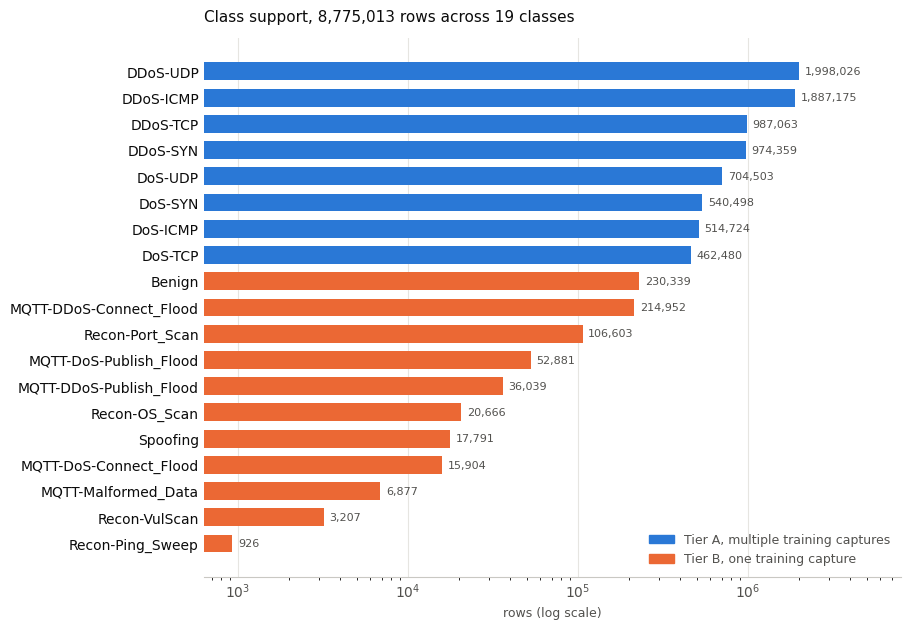

In [13]:
import matplotlib.pyplot as plt

INK, MUTED, GRID, RULE = "#0b0b0b", "#52514e", "#e6e5e1", "#c9c8c3"
TIER_COLOUR = {"A": "#2a78d6", "B": "#eb6834"}
TIER_LABEL = {
    "A": "Tier A, multiple training captures",
    "B": "Tier B, one training capture",
}


def style(ax):
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(RULE)
    ax.tick_params(colors=MUTED, length=0)
    for label in ax.get_yticklabels():
        label.set_color(INK)


def tier_legend(ax):
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=TIER_COLOUR[t], label=TIER_LABEL[t]) for t in ("A", "B")
    ]
    legend = ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=9)
    for text in legend.get_texts():
        text.set_color(MUTED)


plot_order = class_sizes.sort_values("rows")

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    plot_order["label"],
    plot_order["rows"],
    color=[TIER_COLOUR[t] for t in plot_order["tier"]],
    height=0.68,
)
ax.set_xscale("log")
ax.set_xlim(right=plot_order["rows"].max() * 4)
ax.bar_label(
    bars,
    labels=[f"{int(v):,}" for v in plot_order["rows"]],
    padding=4,
    color=MUTED,
    fontsize=8,
)
ax.set_xlabel("rows (log scale)", color=MUTED, fontsize=9)
ax.set_title(
    f"Class support, {TOTAL_ROWS:,} rows across 19 classes",
    color=INK,
    fontsize=11,
    loc="left",
    pad=12,
)
style(ax)
tier_legend(ax)

FIG_SUPPORT = OUT_DIR / "NB02_class_support.png"
fig.savefig(FIG_SUPPORT, dpi=300, bbox_inches="tight", facecolor="white")
print(f"wrote {FIG_SUPPORT}")
plt.show()

wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/NB02_captures_per_class.png


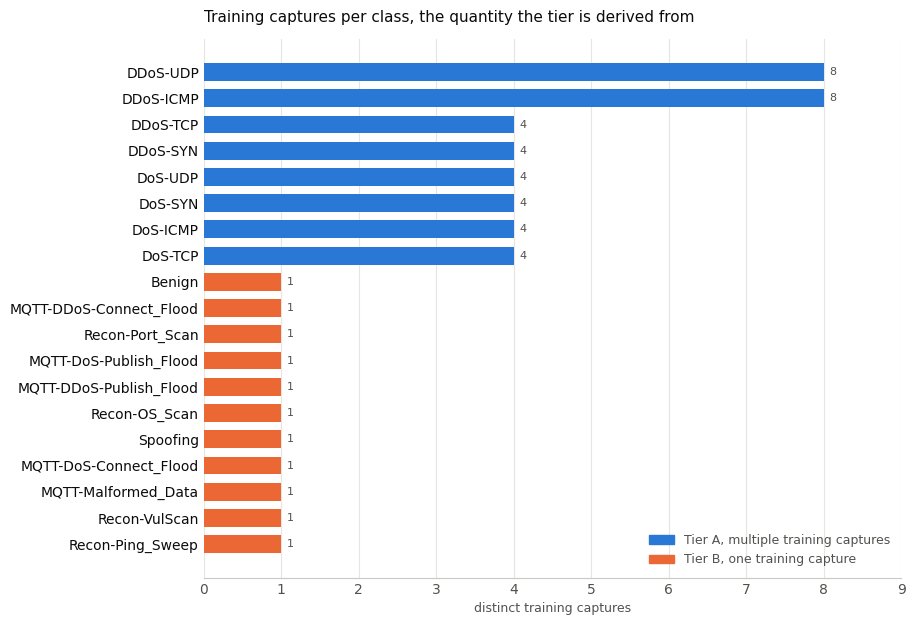

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    plot_order["label"],
    plot_order["n_train_captures"],
    color=[TIER_COLOUR[t] for t in plot_order["tier"]],
    height=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{int(v)}" for v in plot_order["n_train_captures"]],
    padding=4,
    color=MUTED,
    fontsize=8,
)
ax.set_xlim(right=plot_order["n_train_captures"].max() + 1)
ax.set_xlabel("distinct training captures", color=MUTED, fontsize=9)
ax.set_title(
    "Training captures per class, the quantity the tier is derived from",
    color=INK,
    fontsize=11,
    loc="left",
    pad=12,
)
style(ax)
tier_legend(ax)

FIG_CAPTURES = OUT_DIR / "NB02_captures_per_class.png"
fig.savefig(FIG_CAPTURES, dpi=300, bbox_inches="tight", facecolor="white")
print(f"wrote {FIG_CAPTURES}")
plt.show()

Everything the later notebooks need from this one goes into a single file on Drive, so
that the split code reads the tier assignment rather than re-deriving it and getting a
different answer. It records the class to capture mapping, the tiers, the row counts,
the coarser groupings, and the capture-constant candidates.

It is written to the artefacts folder and not into the repository. A notebook running in
Colab has no way to commit, so a file written into the clone lives exactly as long as
the session does.

In [15]:
inventory_doc = {
    "generated_by": "AG_PRAXIS_NB02_class_capture_distribution.ipynb",
    "generated_on": RUN_DATE,
    "git_sha": GIT_SHA,
    "fast_mode": FAST,
    "scan_fraction": SCAN_FRAC,
    "row_counts_exact": True,
    "column_scan_full": SCAN_FULL,
    "n_files": len(parsed),
    "n_classes": int(N_CLASSES),
    "n_captures": int(parsed["capture_id"].nunique()),
    "captures_in_both_partitions": in_both,
    "total_rows": TOTAL_ROWS,
    "imbalance_ratio_19": round(IMBALANCE_RATIO, 3),
    "tiers": {"A": tier_a, "B": tier_b},
    "classes": {
        row["label"]: {
            "tier": row["tier"],
            "group6": row["group6"],
            "group2": row["group2"],
            "rows": int(row["rows"]),
            "pct_of_total": float(row["pct_of_total"]),
            "n_train_captures": int(row["n_train_captures"]),
            "n_test_captures": int(row["n_test_captures"]),
            "captures_train": row["captures_train"],
            "captures_test": row["captures_test"],
        }
        for _, row in class_sizes.iterrows()
    },
    "rows_per_capture_file": {r["file"]: int(r["rows"]) for _, r in parsed.iterrows()},
    "group6_rows": {k: int(v) for k, v in six["rows"].items()},
    "group2_rows": {k: int(v) for k, v in two["rows"].items()},
    "capture_constant_candidates": [
        {
            "column": row["column"],
            "constant_in_files": int(row["constant_in_files"]),
            "of_files": int(row["of_files"]),
            "distinct_values_across_files": int(row["distinct_values_across_files"]),
            "values": row["values"][:20],
        }
        for _, row in flagged.iterrows()
    ],
    "capture_constant_near_misses": [
        {
            "column": row["column"],
            "constant_in_files": int(row["constant_in_files"]),
            "of_files": int(row["of_files"]),
            "distinct_values_across_files": int(row["distinct_values_across_files"]),
        }
        for _, row in partial.iterrows()
    ],
    "columns_constant_everywhere": dead["column"].tolist(),
}

INVENTORY_PATH = OUT_DIR / "capture_inventory.json"
INVENTORY_PATH.write_text(json.dumps(cap.jsonable(inventory_doc), indent=2) + "\n")

for path in (INVENTORY_PATH, FIG_SUPPORT, FIG_CAPTURES):
    print(f"wrote {path}   {path.stat().st_size:,} bytes")
print()
print(f"nothing was written into {REPO_ROOT}")

wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/capture_inventory.json   12,174 bytes
wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/NB02_class_support.png   287,660 bytes
wrote /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/NB02_captures_per_class.png   231,850 bytes

nothing was written into /content/repo


Files on Drive are one copy. The output of a cell saved with the notebook is another, and
it is the one that stays attached to the run that produced it. So every JSON and YAML
file in the output folder is read back from disk and printed here in full, whatever ends
up being written there.

In [16]:
generated = sorted(p for p in OUT_DIR.iterdir() if p.suffix.lower() in (".json", ".yaml", ".yml"))
images = sorted(p for p in OUT_DIR.iterdir() if p.suffix.lower() == ".png")

print(f"{len(generated)} text file(s) and {len(images)} image(s) in {OUT_DIR}")
print()

for path in generated:
    print("=" * 79)
    print(f"{path.name}   ({path.stat().st_size:,} bytes)")
    print("=" * 79)
    print(path.read_text().rstrip())
    print()

print("=" * 79)
print("images, which cannot be printed")
print("=" * 79)
for path in images:
    print(f"{path.name}   {path.stat().st_size:,} bytes")

1 text file(s) and 2 image(s) in /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02

capture_inventory.json   (12,174 bytes)
{
  "generated_by": "AG_PRAXIS_NB02_class_capture_distribution.ipynb",
  "generated_on": "2026-08-02",
  "git_sha": "ba7bd64",
  "fast_mode": true,
  "scan_fraction": 0.01,
  "row_counts_exact": true,
  "column_scan_full": false,
  "n_files": 72,
  "n_classes": 19,
  "n_captures": 57,
  "captures_in_both_partitions": [
    "ARP_Spoofing",
    "Benign",
    "MQTT-DDoS-Connect_Flood",
    "MQTT-DDoS-Publish_Flood",
    "MQTT-DoS-Connect_Flood",
    "MQTT-DoS-Publish_Flood",
    "MQTT-Malformed_Data",
    "Recon-OS_Scan",
    "Recon-Ping_Sweep",
    "Recon-Port_Scan",
    "Recon-VulScan",
    "TCP_IP-DDoS-ICMP1",
    "TCP_IP-DDoS-ICMP2",
    "TCP_IP-DDoS-UDP1",
    "TCP_IP-DDoS-UDP2"
  ],
  "total_rows": 8775013,
  "imbalance_ratio_19": 2157.695,
  "tiers": {
    "A": [
      "DDoS-ICMP",
      "DDoS-SYN",
      "DDoS-TCP",
      "DDoS-UDP",
      "DoS-ICMP",
      "Do

The entry for `RESULTS_LEDGER.md`, ready to paste.

In [17]:
status = "reference run" if SCAN_FULL else "EXPLORATORY, FAST=1, column checks are a screen, do not enter in the ledger"

ledger = f"""
### NB02 — class and capture distribution ({RUN_DATE})

| field | value |
|---|---|
| notebook | AG_PRAXIS_NB02_class_capture_distribution.ipynb |
| run date | {RUN_DATE} |
| git sha | {GIT_SHA}{" (working tree dirty)" if GIT_DIRTY else ""} |
| seed | {SEED} |
| FAST | {int(FAST)} |
| status | {status} |
| files parsed | {len(parsed)} of {EXPECTED_FILES} expected |
| columns, from schema.json | {SCHEMA["n_columns"]} |
| classes | {N_CLASSES} |
| captures | {parsed['capture_id'].nunique()} |
| captures split across both partitions | {len(in_both)} |
| tier A / tier B | {len(tier_a)} / {len(tier_b)} |
| total rows | {TOTAL_ROWS:,} |
| largest class | {largest['label']}, {int(largest['rows']):,} rows, {largest['pct_of_total']}% |
| smallest class | {smallest['label']}, {int(smallest['rows']):,} rows, {smallest['pct_of_total']}% |
| imbalance ratio, 19-class | {IMBALANCE_RATIO:,.1f} to 1 |
| imbalance ratio, 6-class | {six['rows'].max() / max(six['rows'].min(), 1):,.1f} to 1 |
| imbalance ratio, 2-class | {two['rows'].max() / max(two['rows'].min(), 1):,.1f} to 1 |
| capture-constant feature columns | {len(flagged)} |
| columns constant everywhere | {len(dead)} |
| metrics | none, no model trained |
| artefacts | {OUT_DIR}, holding capture_inventory.json and two figures |

Tier B classes, which admit no capture-disjoint split: {", ".join(tier_b)}
"""

print(ledger)


### NB02 — class and capture distribution (2026-08-02)

| field | value |
|---|---|
| notebook | AG_PRAXIS_NB02_class_capture_distribution.ipynb |
| run date | 2026-08-02 |
| git sha | ba7bd64 |
| seed | 42 |
| FAST | 1 |
| status | EXPLORATORY, FAST=1, column checks are a screen, do not enter in the ledger |
| files parsed | 72 of 72 expected |
| columns, from schema.json | 45 |
| classes | 19 |
| captures | 57 |
| captures split across both partitions | 15 |
| tier A / tier B | 8 / 11 |
| total rows | 8,775,013 |
| largest class | DDoS-UDP, 1,998,026 rows, 22.769% |
| smallest class | Recon-Ping_Sweep, 926 rows, 0.011% |
| imbalance ratio, 19-class | 2,157.7 to 1 |
| imbalance ratio, 6-class | 328.6 to 1 |
| imbalance ratio, 2-class | 37.1 to 1 |
| capture-constant feature columns | 0 |
| columns constant everywhere | 2 |
| metrics | none, no model trained |
| artefacts | /content/drive/MyDrive/AG_PRAXIS_artifacts/NB02, holding capture_inventory.json and two figures |

Tier B classe

In [18]:
import json
inv = json.load(open('/content/drive/MyDrive/AG_PRAXIS_artifacts/NB02/capture_inventory.json'))
print(json.dumps(inv, indent=2)[:3000])

{
  "generated_by": "AG_PRAXIS_NB02_class_capture_distribution.ipynb",
  "generated_on": "2026-08-02",
  "git_sha": "ba7bd64",
  "fast_mode": true,
  "scan_fraction": 0.01,
  "row_counts_exact": true,
  "column_scan_full": false,
  "n_files": 72,
  "n_classes": 19,
  "n_captures": 57,
  "captures_in_both_partitions": [
    "ARP_Spoofing",
    "Benign",
    "MQTT-DDoS-Connect_Flood",
    "MQTT-DDoS-Publish_Flood",
    "MQTT-DoS-Connect_Flood",
    "MQTT-DoS-Publish_Flood",
    "MQTT-Malformed_Data",
    "Recon-OS_Scan",
    "Recon-Ping_Sweep",
    "Recon-Port_Scan",
    "Recon-VulScan",
    "TCP_IP-DDoS-ICMP1",
    "TCP_IP-DDoS-ICMP2",
    "TCP_IP-DDoS-UDP1",
    "TCP_IP-DDoS-UDP2"
  ],
  "total_rows": 8775013,
  "imbalance_ratio_19": 2157.695,
  "tiers": {
    "A": [
      "DDoS-ICMP",
      "DDoS-SYN",
      "DDoS-TCP",
      "DDoS-UDP",
      "DoS-ICMP",
      "DoS-SYN",
      "DoS-TCP",
      "DoS-UDP"
    ],
    "B": [
      "Benign",
      "MQTT-DDoS-Connect_Flood",
      "MQTT-DD